In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

RESULTS_DIR = Path(r"C:\Users\MaryBeth\projects\SarvestaniLab\OpenScopeMouseV1\jupyternotebooks\ephys\results")

# Load response matrix and RF locations
response_matrix = np.load(RESULTS_DIR / "ephys_response_matrix.npy")
unit_ids_df     = pd.read_csv(RESULTS_DIR / "ephys_unit_ids.csv")
rf_df           = pd.read_csv(RESULTS_DIR / "ephys_rf_unit_info.csv")
pref_df         = pd.read_csv(RESULTS_DIR / "ephys_pref_variables.csv")

# Predict RF location (x, y) from response matrix — simple MLP

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Merge to align RF x,y with response matrix rows
merged = unit_ids_df.merge(rf_df[['unit_id', 'rf_center_x', 'rf_center_y', 'rf_r_squared']], on='unit_id', how='left')
valid  = (
    merged['rf_center_x'].notna() & merged['rf_center_y'].notna() &
    (merged['rf_center_x'] != 40)  & (merged['rf_center_x'] != -40) &
    (merged['rf_center_y'] != 40)  & (merged['rf_center_y'] != -40) &
    (merged['rf_r_squared'] >= 0.5)
)

X = response_matrix[valid.values]                                          # features: response matrix
Y = merged.loc[valid, ['rf_center_x', 'rf_center_y']].values              # targets: RF x, y

# Z-score each unit's response across conditions
X = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-8)

print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")


X shape: (3873, 100)
Y shape: (3873, 2)


In [3]:
N = 9  # 9x9 grid

# --- Bin on the full dataset so train/test share one fixed grid ---
x_edges = np.linspace(Y[:, 0].min(), Y[:, 0].max(), N + 1)
y_edges = np.linspace(Y[:, 1].min(), Y[:, 1].max(), N + 1)
bx = np.clip(np.digitize(Y[:, 0], x_edges[1:-1]), 0, N - 1)
by = np.clip(np.digitize(Y[:, 1], y_edges[1:-1]), 0, N - 1)
labels = by * N + bx                       # single class 0..80

# Drop bins with only 1 neuron (can't stratify-split)
counts = np.bincount(labels, minlength=N * N)
keep = counts[labels] >= 2
X_k, Y_k, labels_k = X[keep], Y[keep], labels[keep]
print(f"Dropped {(~keep).sum()} singleton-bin units, {keep.sum()} remaining")

# --- Stratified split: carries X, continuous Y, and bin labels together ---
X_train, X_test, Y_train, Y_test, lbl_train, lbl_test = train_test_split(
    X_k, Y_k, labels_k,
    test_size=0.2,
    random_state=42,
    stratify=labels_k,
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# --- Regularized classifier ---
clf = MLPClassifier(
    hidden_layer_sizes=(64,),
    alpha=1.0,                 # strong L2
    early_stopping=True,
    n_iter_no_change=15,
    max_iter=1000,
    random_state=42,
)
clf.fit(X_train, lbl_train)

pred = clf.predict(X_test)
px, py = pred % N, pred // N               # decode predicted grid coords
tx, ty = lbl_test % N, lbl_test // N       # decode true grid coords


Dropped 1 singleton-bin units, 3872 remaining


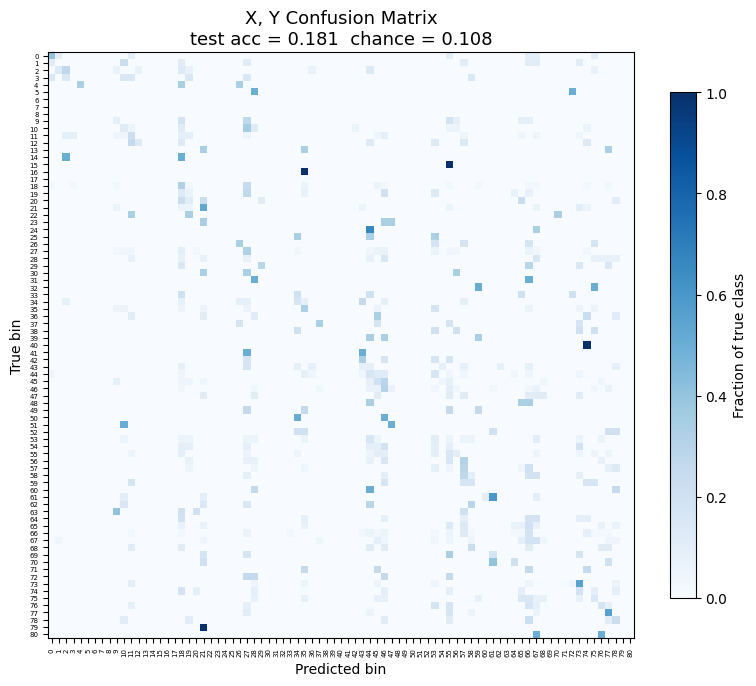

In [4]:
from sklearn.metrics import confusion_matrix, accuracy_score, balanced_accuracy_score

bin_labels = list(range(N * N))  # 0..80

fig, ax = plt.subplots(figsize=(8, 7))

cm = confusion_matrix(lbl_test, pred, labels=bin_labels, normalize='true')
im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1, origin='lower')
ax.set_xticks(range(len(bin_labels)))
ax.set_xticklabels(bin_labels, fontsize=5, rotation=90)
ax.set_yticks(range(len(bin_labels)))
ax.set_yticklabels(bin_labels, fontsize=5)
ax.set_xlabel("Predicted bin")
ax.set_ylabel("True bin")

acc     = accuracy_score(lbl_test, pred)
bal_acc = balanced_accuracy_score(lbl_test, pred)

plt.colorbar(im, ax=ax, label="Fraction of true class", shrink=0.8)
plt.gca().invert_yaxis()

plt.title(f"X, Y Confusion Matrix\ntest acc = {acc:.3f}  chance = {bal_acc:.3f}", fontsize=13)
fig.tight_layout()
plt.show()

# Predict Probe from response matrix — simple MLP

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import normalize

# Merge to align RF x,y with response matrix rows
merged = unit_ids_df.merge(rf_df[['unit_id', 'rf_center_x', 'rf_center_y', 'rf_r_squared', 'probe', 'mouse_name', 'snr']], on='unit_id', how='left')
mask  = (
    merged['rf_center_x'].notna() & merged['rf_center_y'].notna() &
    (merged['rf_r_squared'] >= 0.5)
)

# mask  = (
#     merged['rf_center_x'].notna() & merged['rf_center_y'].notna() &
#     (merged['rf_center_x'] != 40)  & (merged['rf_center_x'] != -40) &
#     (merged['rf_center_y'] != 40)  & (merged['rf_center_y'] != -40) &
#     (merged['rf_r_squared'] >= 0.5)
# )

# X = response_matrix[valid.values]                                          # features: response matrix
# Y = merged.loc[valid, ['probe']].values              # targets: RF x, y

# # Z-score each unit's response across conditions
# X = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-8)

# print(f"X shape: {X.shape}")
# print(f"Y shape: {Y.shape}")


rf_df_filtered = merged[mask]
print(f"Filtered RF info shape: {rf_df_filtered.shape}")

unit_ids_df_filtered = unit_ids_df[unit_ids_df["unit_id"].isin(rf_df_filtered["unit_id"])]
print(f"Filtered unit IDs shape: {unit_ids_df_filtered.shape}")

response_matrix_filtered = response_matrix[unit_ids_df["unit_id"].isin(rf_df_filtered["unit_id"])]
print(f"Filtered response matrix shape: {response_matrix_filtered.shape}")

Filtered RF info shape: (5648, 7)
Filtered unit IDs shape: (5648, 1)
Filtered response matrix shape: (5648, 100)


In [6]:
norms_raw = np.linalg.norm(response_matrix_filtered, axis=1)
nonzero_mask = norms_raw > 0
print(f"  Dropping {(~nonzero_mask).sum()} silent units")

response_matrix_filtered = response_matrix_filtered[nonzero_mask]
unit_ids_df_filtered        = unit_ids_df_filtered.iloc[nonzero_mask].reset_index(drop=True)
rf_df_filtered              = rf_df_filtered.iloc[nonzero_mask].reset_index(drop=True)

### adding in removing rate axis ###
response_meansub = response_matrix_filtered - response_matrix_filtered.mean(axis=1, keepdims=True)
response_norm = normalize(response_meansub, norm='l2')

  Dropping 15 silent units


In [7]:
X = response_norm
Y = rf_df_filtered[['probe']].values

print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")

X shape: (5633, 100)
Y shape: (5633, 1)


In [8]:
from sklearn.preprocessing import LabelEncoder

labels = Y[:, 0]   # probe name strings

# Drop any singletons
unique, counts = np.unique(labels, return_counts=True)
keep = np.isin(labels, unique[counts >= 2])
X_k, labels_k = X[keep], labels[keep]
#print(f"Probes: {dict(zip(unique, counts))}")
print(f"Dropped {(~keep).sum()} singleton units, {keep.sum()} remaining")

# Encode string labels as integers
le = LabelEncoder()
labels_enc = le.fit_transform(labels_k)

# --- Stratified split ---
X_train, X_test, lbl_train, lbl_test = train_test_split(
    X_k, labels_enc,
    test_size=0.2,
    random_state=42,
    stratify=labels_enc,
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# --- Regularized classifier ---
clf = MLPClassifier(
    hidden_layer_sizes=(64,),
    alpha=1.0,
    early_stopping=True,
    n_iter_no_change=15,
    max_iter=1000,
    random_state=42,
)
clf.fit(X_train, lbl_train)

pred = clf.predict(X_test)

class_counts = np.bincount(labels_enc)
# weights = class_counts / class_counts.sum()
# weighted_chance = (weights ** 2).sum()  # sum of p_i^2
chance = class_counts.max() / class_counts.sum()
acc = (pred == lbl_test).mean()

print(f"\nTest accuracy: {acc:.3f}  (weighted chance = {chance:.3f},  n probes = {len(le.classes_)})")


Dropped 0 singleton units, 5633 remaining

Test accuracy: 0.622  (weighted chance = 0.297,  n probes = 4)


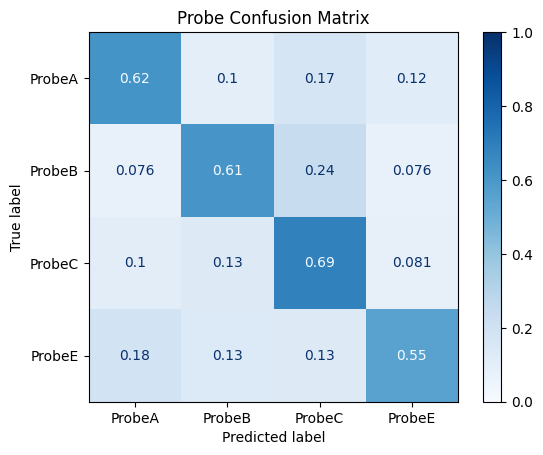

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(lbl_test, pred, normalize='true')
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
disp.im_.set_clim(0, 1)
plt.title("Probe Confusion Matrix")
plt.show()

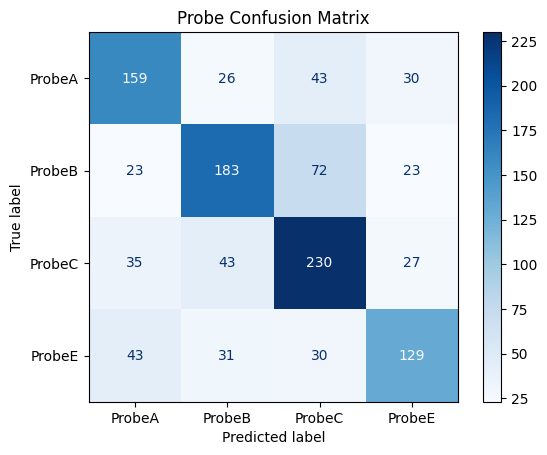

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(lbl_test, pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title("Probe Confusion Matrix")
plt.show()

In [11]:
n_permutations = 100
perm_accs = []

for i in range(n_permutations):
    lbl_perm = np.random.permutation(labels_enc)
    Xtr, Xte, ltr, lte = train_test_split(X_k, lbl_perm, test_size=0.2, random_state=i, stratify=lbl_perm)
    sc = StandardScaler()
    Xtr = sc.fit_transform(Xtr)
    Xte = sc.transform(Xte)
    clf_p = MLPClassifier(hidden_layer_sizes=(64,), alpha=1.0, early_stopping=True, n_iter_no_change=15, max_iter=1000, random_state=i)
    clf_p.fit(Xtr, ltr)
    perm_accs.append((clf_p.predict(Xte) == lte).mean())

p_val = (np.array(perm_accs) >= acc).mean()
print(f"Permutation p-value: {p_val:.4f}")

Permutation p-value: 0.0000


In [12]:
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', MLPClassifier(hidden_layer_sizes=(64,), alpha=1.0, early_stopping=True, n_iter_no_change=15, max_iter=1000, random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
for tr, te in cv.split(X_k, labels_enc):
    pipe.fit(X_k[tr], labels_enc[tr])
    cv_scores.append((pipe.predict(X_k[te]) == labels_enc[te]).mean())

print(f"CV accuracy: {np.mean(cv_scores):.3f} ± {np.std(cv_scores):.3f}")

CV accuracy: 0.600 ± 0.018


Running per-mouse probe prediction for 8 mice...
sub-810531: acc=0.643  chance=0.291  n_units=766  probes=['ProbeA', 'ProbeB', 'ProbeC', 'ProbeE']
sub-810532: acc=0.682  chance=0.314  n_units=548  probes=['ProbeA', 'ProbeB', 'ProbeC', 'ProbeE']
sub-813810: acc=0.637  chance=0.278  n_units=909  probes=['ProbeA', 'ProbeB', 'ProbeC', 'ProbeE']
sub-815152: acc=0.565  chance=0.325  n_units=837  probes=['ProbeA', 'ProbeB', 'ProbeC', 'ProbeE']
sub-816305: acc=0.655  chance=0.342  n_units=579  probes=['ProbeA', 'ProbeB', 'ProbeC', 'ProbeE']
sub-816308: acc=0.646  chance=0.517  n_units=493  probes=['ProbeA', 'ProbeB', 'ProbeC', 'ProbeE']
sub-817334: acc=0.554  chance=0.322  n_units=692  probes=['ProbeA', 'ProbeB', 'ProbeC', 'ProbeE']
sub-817335: acc=0.568  chance=0.304  n_units=809  probes=['ProbeA', 'ProbeB', 'ProbeC', 'ProbeE']
All:    acc=0.622  chance=0.297  n_units=5633  probes=['ProbeA', 'ProbeB', 'ProbeC', 'ProbeE']


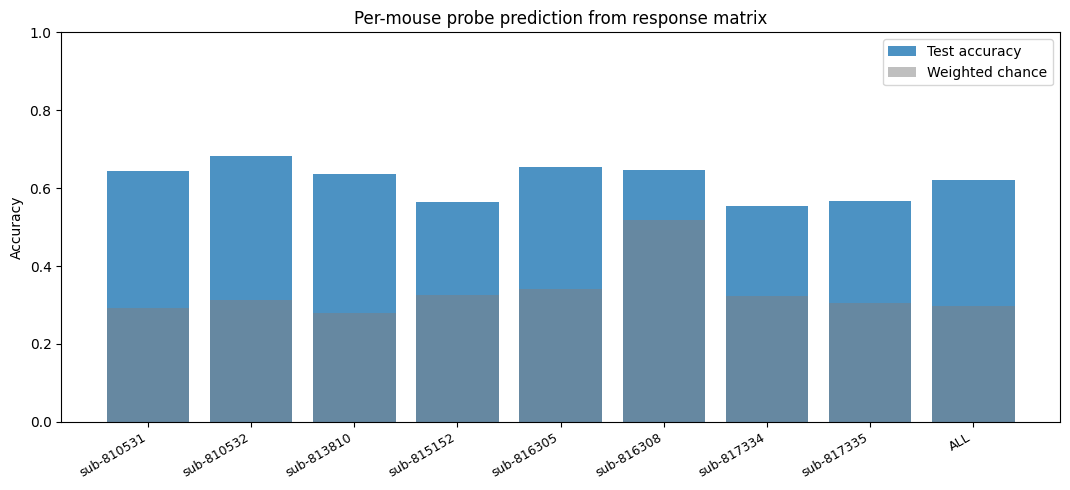

In [13]:
# ── Predict probe from response matrix, separately per mouse ─────────────────
# This tests whether probe is predictable within a single animal,
# ruling out the concern that we are just detecting mouse-to-mouse variability.

mouse_names = rf_df_filtered['mouse_name'].values
unique_mice = sorted(set(mouse_names))
print(f"Running per-mouse probe prediction for {len(unique_mice)} mice...")

results = []
for mouse in unique_mice:
    mask_m = mouse_names == mouse
    X_m = X_k[mask_m[keep]]   # restrict mask to the same units used globally
    lbl_m = rf_df_filtered['probe'].values[keep][mask_m[keep]]

    unique_p, counts_p = np.unique(lbl_m, return_counts=True)
    # Need at least 2 probes with >= 2 units to run a classifier
    valid_p = unique_p[counts_p >= 2]
    if len(valid_p) < 2:
        print(f"{mouse}: skipped (fewer than 2 probes with enough units)")
        results.append({'mouse': mouse, 'acc': np.nan, 'chance': np.nan, 'n_units': mask_m.sum(), 'n_probes': len(unique_p)})
        continue

    keep_m = np.isin(lbl_m, valid_p)
    X_mk, lbl_mk = X_m[keep_m], lbl_m[keep_m]

    le_m = LabelEncoder()
    lbl_enc_m = le_m.fit_transform(lbl_mk)

    class_counts_m = np.bincount(lbl_enc_m)
    # weights_m  = class_counts_m / class_counts_m.sum()
    # chance_m   = (weights_m ** 2).sum()
    chance_m = class_counts_m.max() / class_counts_m.sum()

    try:
        X_tr_m, X_te_m, lbl_tr_m, lbl_te_m = train_test_split(
            X_mk, lbl_enc_m, test_size=0.2, random_state=42, stratify=lbl_enc_m
        )
    except ValueError as e:
        print(f"{mouse}: skipped ({e})")
        results.append({'mouse': mouse, 'acc': np.nan, 'chance': chance_m, 'n_units': mask_m.sum(), 'n_probes': len(valid_p)})
        continue

    sc_m = StandardScaler()
    X_tr_m = sc_m.fit_transform(X_tr_m)
    X_te_m = sc_m.transform(X_te_m)

    clf_m = MLPClassifier(hidden_layer_sizes=(64,), alpha=1.0,
                          early_stopping=True, n_iter_no_change=15,
                          max_iter=1000, random_state=42)
    clf_m.fit(X_tr_m, lbl_tr_m)
    pred_m = clf_m.predict(X_te_m)
    acc_m  = (pred_m == lbl_te_m).mean()

    print(f"{mouse}: acc={acc_m:.3f}  chance={chance_m:.3f}  n_units={mask_m.sum()}  probes={list(le_m.classes_)}")
    results.append({'mouse': mouse, 'acc': acc_m, 'chance': chance_m, 'n_units': int(mask_m.sum()), 'n_probes': len(valid_p)})

# ── All mice combined ────────────────────────────────────────────────────────
unique_all, counts_all = np.unique(rf_df_filtered['probe'].values, return_counts=True)
keep_all   = np.isin(rf_df_filtered['probe'].values, unique_all[counts_all >= 2])
X_all      = X[keep_all]
lbl_all    = rf_df_filtered['probe'].values[keep_all]
le_all     = LabelEncoder()
lbl_enc_all = le_all.fit_transform(lbl_all)
class_counts_all = np.bincount(lbl_enc_all)
# weights_all  = class_counts_all / class_counts_all.sum()
# chance_all   = (weights_all ** 2).sum()
chance_all = class_counts_all.max() / class_counts_all.sum()
X_tr_all, X_te_all, lbl_tr_all, lbl_te_all = train_test_split(
    X_all, lbl_enc_all, test_size=0.2, random_state=42, stratify=lbl_enc_all
)
sc_all  = StandardScaler()
X_tr_all = sc_all.fit_transform(X_tr_all)
X_te_all = sc_all.transform(X_te_all)
clf_all  = MLPClassifier(hidden_layer_sizes=(64,), alpha=1.0,
                          early_stopping=True, n_iter_no_change=15,
                          max_iter=1000, random_state=42)
clf_all.fit(X_tr_all, lbl_tr_all)
pred_all = clf_all.predict(X_te_all)
acc_all  = (pred_all == lbl_te_all).mean()
print(f"All:    acc={acc_all:.3f}  chance={chance_all:.3f}  n_units={len(X_all)}  probes={list(le_all.classes_)}")
results.append({'mouse': 'ALL', 'acc': acc_all, 'chance': chance_all, 'n_units': len(X_all), 'n_probes': len(le_all.classes_)})

# ── Summary plot ──────────────────────────────────────────────────────────────
results_df = pd.DataFrame(results).dropna(subset=['acc'])
x = np.arange(len(results_df))

fig, ax = plt.subplots(figsize=(max(6, len(results_df) * 1.2), 5))
ax.bar(x, results_df['acc'],   label='Test accuracy', alpha=0.8)
ax.bar(x, results_df['chance'], label='Weighted chance', alpha=0.5, color='gray')
ax.set_xticks(x)
ax.set_xticklabels(results_df['mouse'], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Accuracy')
ax.set_title('Per-mouse probe prediction from response matrix')
ax.legend()
ax.set_ylim(0, 1)
fig.tight_layout()
plt.show()


# Predict Pref SF x TF from response matrix -- simple MLP

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, normalize

merged = unit_ids_df.merge(
    rf_df[["unit_id", "rf_center_x", "rf_center_y", "rf_r_squared"]],
    on="unit_id", how="left"
).merge(
    pref_df[["unit_id", "pref_sf", "pref_tf"]],
    on="unit_id", how="left"
)

mask = (
    (merged["rf_r_squared"] >= 0.5)
    & (merged["pref_sf"].notna())
    & (merged["pref_tf"].notna())
)

rf_df_filtered_sftf   = merged[mask].reset_index(drop=True)
response_mat_sftf     = response_matrix[unit_ids_df["unit_id"].isin(rf_df_filtered_sftf["unit_id"])]
unit_ids_sftf         = unit_ids_df[unit_ids_df["unit_id"].isin(rf_df_filtered_sftf["unit_id"])]
print(f"Units with valid pref SF/TF: {rf_df_filtered_sftf.shape[0]}")

# Drop silent units and normalize
norms = np.linalg.norm(response_mat_sftf, axis=1)
nonzero = norms > 0
response_mat_sftf   = response_mat_sftf[nonzero]
rf_df_filtered_sftf = rf_df_filtered_sftf.iloc[nonzero].reset_index(drop=True)
print(f"After dropping silent units: {response_mat_sftf.shape[0]}")

response_meansub = response_mat_sftf - response_mat_sftf.mean(axis=1, keepdims=True)
X_sftf = normalize(response_meansub, norm="l2")


Units with valid pref SF/TF: 5648
After dropping silent units: 5633


In [15]:
# Combined (pref_sf, pref_tf) label
sf_raw = rf_df_filtered_sftf["pref_sf"].values
tf_raw = rf_df_filtered_sftf["pref_tf"].values
label_str = np.array([f"({round(s,4)},{round(t,4)})" for s, t in zip(sf_raw, tf_raw)])

le_sftf = LabelEncoder()
labels_enc = le_sftf.fit_transform(label_str)
print(f"Unique (pref_sf, pref_tf) combinations: {len(le_sftf.classes_)}")

# Drop singletons
counts = np.bincount(labels_enc)
keep = counts[labels_enc] >= 2
X_k, labels_k = X_sftf[keep], labels_enc[keep]
sf_k, tf_k    = sf_raw[keep], tf_raw[keep]
print(f"Dropped {(~keep).sum()} singleton units, {keep.sum()} remaining")

X_train_sftf, X_test_sftf, lbl_train_sftf, lbl_test_sftf = train_test_split(
    X_k, labels_k, test_size=0.2, random_state=42, stratify=labels_k)

scaler = StandardScaler()
X_train_sftf = scaler.fit_transform(X_train_sftf)  # BUG 1: was using X_train/X_test instead of X_train_sftf/X_test_sftf
X_test_sftf  = scaler.transform(X_test_sftf)

clf_sftf = MLPClassifier(
    hidden_layer_sizes=(64,),
    alpha=1.0,
    early_stopping=True,
    n_iter_no_change=15,
    max_iter=1000,
    random_state=42,
)
clf_sftf.fit(X_train_sftf, lbl_train_sftf)
pred_sftf = clf_sftf.predict(X_test_sftf)

chance = np.bincount(labels_k).max() / len(labels_k)
acc_sftf = (pred_sftf == lbl_test_sftf).mean()  # BUG 2: was using lbl_test instead of lbl_test_sftf
print(f"\nTest accuracy: {acc_sftf:.3f}  (majority-class chance = {chance:.3f},  n classes = {len(le_sftf.classes_)})")

Unique (pref_sf, pref_tf) combinations: 25
Dropped 0 singleton units, 5633 remaining

Test accuracy: 0.831  (majority-class chance = 0.155,  n classes = 25)


In [16]:
print("Num classes:", len(le_sftf.classes_))

print("Test class distribution:")
for cls_idx, count in zip(*np.unique(lbl_test_sftf, return_counts=True)):      # ← change to lbl_test_sftf
    print(f"  {le_sftf.classes_[cls_idx]}: {count} samples")

print("\nTrain class distribution:")
for cls_idx, count in zip(*np.unique(lbl_train_sftf, return_counts=True)):     # ← change to lbl_train_sftf
    print(f"  {le_sftf.classes_[cls_idx]}: {count} samples")

Num classes: 25
Test class distribution:
  (0.02,1.0): 147 samples
  (0.02,15.0): 46 samples
  (0.02,2.0): 45 samples
  (0.02,4.0): 29 samples
  (0.02,8.0): 33 samples
  (0.04,1.0): 103 samples
  (0.04,15.0): 20 samples
  (0.04,2.0): 35 samples
  (0.04,4.0): 16 samples
  (0.04,8.0): 18 samples
  (0.08,1.0): 67 samples
  (0.08,15.0): 20 samples
  (0.08,2.0): 26 samples
  (0.08,4.0): 17 samples
  (0.08,8.0): 22 samples
  (0.16,1.0): 117 samples
  (0.16,15.0): 17 samples
  (0.16,2.0): 41 samples
  (0.16,4.0): 21 samples
  (0.16,8.0): 19 samples
  (0.32,1.0): 175 samples
  (0.32,15.0): 25 samples
  (0.32,2.0): 31 samples
  (0.32,4.0): 22 samples
  (0.32,8.0): 15 samples

Train class distribution:
  (0.02,1.0): 589 samples
  (0.02,15.0): 186 samples
  (0.02,2.0): 182 samples
  (0.02,4.0): 117 samples
  (0.02,8.0): 131 samples
  (0.04,1.0): 413 samples
  (0.04,15.0): 79 samples
  (0.04,2.0): 139 samples
  (0.04,4.0): 67 samples
  (0.04,8.0): 72 samples
  (0.08,1.0): 267 samples
  (0.08,15.0)

In [17]:
counts = np.bincount(labels_enc)
for i, (cls, cnt) in enumerate(zip(le_sftf.classes_, counts)):
    print(f"  {cls}: {cnt} samples")

  (0.02,1.0): 736 samples
  (0.02,15.0): 232 samples
  (0.02,2.0): 227 samples
  (0.02,4.0): 146 samples
  (0.02,8.0): 164 samples
  (0.04,1.0): 516 samples
  (0.04,15.0): 99 samples
  (0.04,2.0): 174 samples
  (0.04,4.0): 83 samples
  (0.04,8.0): 90 samples
  (0.08,1.0): 334 samples
  (0.08,15.0): 100 samples
  (0.08,2.0): 130 samples
  (0.08,4.0): 85 samples
  (0.08,8.0): 108 samples
  (0.16,1.0): 584 samples
  (0.16,15.0): 84 samples
  (0.16,2.0): 203 samples
  (0.16,4.0): 106 samples
  (0.16,8.0): 93 samples
  (0.32,1.0): 874 samples
  (0.32,15.0): 126 samples
  (0.32,2.0): 156 samples
  (0.32,4.0): 109 samples
  (0.32,8.0): 74 samples


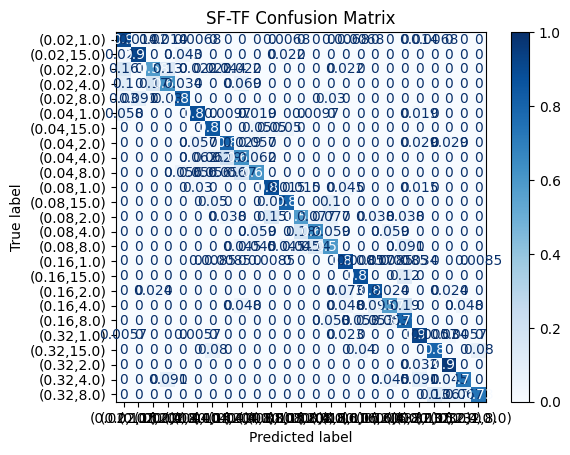

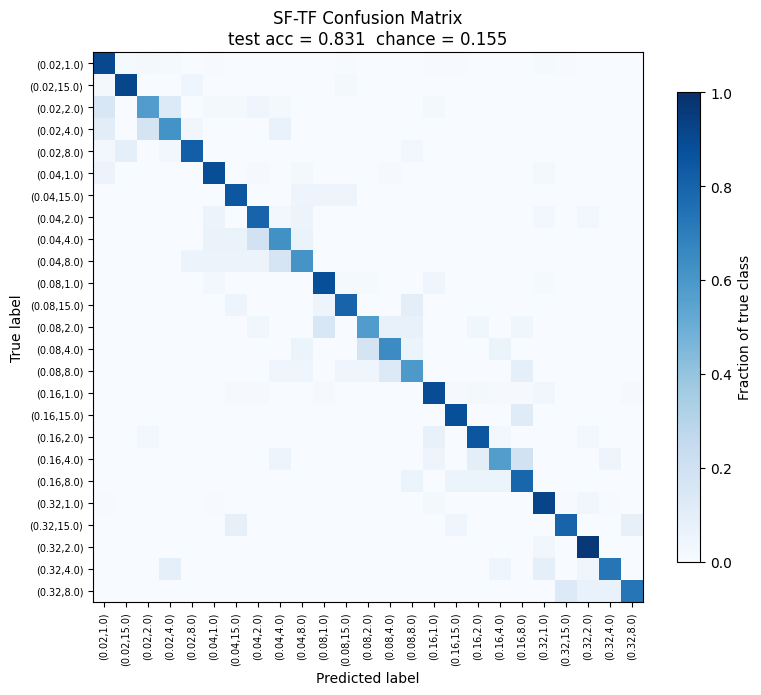

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(lbl_test_sftf, pred_sftf, normalize='true')
disp = ConfusionMatrixDisplay(cm, display_labels=le_sftf.classes_)
disp.plot(cmap='Blues')
disp.im_.set_clim(0, 1)
plt.title("SF-TF Confusion Matrix")
plt.show()

# SF-TF
classes_in_test = np.unique(lbl_test_sftf)
class_labels = le_sftf.classes_[classes_in_test]
n = len(classes_in_test)

cm = confusion_matrix(lbl_test_sftf, pred_sftf, labels=classes_in_test, normalize="true")

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(n))
ax.set_xticklabels(class_labels, fontsize=7, rotation=90)
ax.set_yticks(range(n))
ax.set_yticklabels(class_labels, fontsize=7)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
plt.colorbar(im, ax=ax,  label="Fraction of true class", shrink=0.8)
plt.title(f"SF-TF Confusion Matrix\ntest acc = {acc_sftf:.3f}  chance = {chance:.3f}")
plt.tight_layout()
plt.show()

Permutation p-value: 0.0000


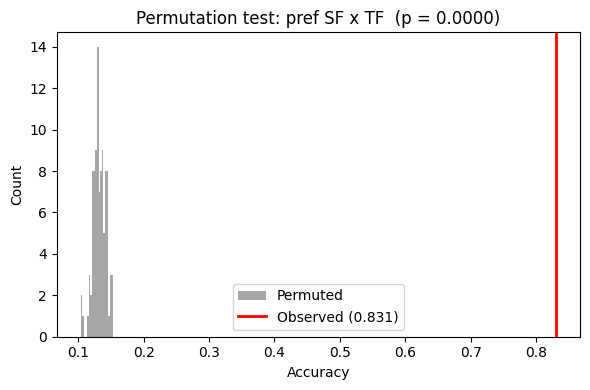

In [19]:
n_permutations = 100
perm_accs_sftf = []

for i in range(n_permutations):
    lbl_perm = np.random.permutation(labels_k)
    Xtr, Xte, ltr, lte = train_test_split(X_k, lbl_perm, test_size=0.2,
                                           random_state=i, stratify=lbl_perm)
    sc = StandardScaler()
    Xtr = sc.fit_transform(Xtr)
    Xte = sc.transform(Xte)
    clf_p = MLPClassifier(hidden_layer_sizes=(64,), alpha=1.0,
                          early_stopping=True, n_iter_no_change=15,
                          max_iter=1000, random_state=i)
    clf_p.fit(Xtr, ltr)
    perm_accs_sftf.append((clf_p.predict(Xte) == lte).mean())

p_val_sftf = (np.array(perm_accs_sftf) >= acc_sftf).mean()
print(f"Permutation p-value: {p_val_sftf:.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(perm_accs_sftf, bins=20, color="gray", alpha=0.7, label="Permuted")
ax.axvline(acc_sftf, color="red", lw=2, label=f"Observed ({acc_sftf:.3f})")
ax.set_xlabel("Accuracy")
ax.set_ylabel("Count")
ax.set_title(f"Permutation test: pref SF x TF  (p = {p_val_sftf:.4f})")
ax.legend()
fig.tight_layout()
plt.show()


In [20]:
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline

pipe_sftf = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(hidden_layer_sizes=(64,), alpha=1.0,
                          early_stopping=True, n_iter_no_change=15,
                          max_iter=1000, random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_sftf = []
for tr, te in cv.split(X_k, labels_k):
    pipe_sftf.fit(X_k[tr], labels_k[tr])
    cv_scores_sftf.append((pipe_sftf.predict(X_k[te]) == labels_k[te]).mean())

print(f"CV accuracy: {np.mean(cv_scores_sftf):.3f} +/- {np.std(cv_scores_sftf):.3f}")


CV accuracy: 0.839 +/- 0.013
